In [27]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [6]:
# Define the parent directory where the analysis folders are stored
parent_dir = "/gpfs/commons/home/kisaev/Leaflet-private/temp/sep5/"

# List to store all dataframes
all_dfs = []

# Loop over each subdirectory
for root, dirs, files in os.walk(parent_dir):
    # Look for .csv files
    for file in files:
        if file.endswith(".csv"):
            # Extract metadata from the directory name
            dir_name = os.path.basename(root)
            parts = dir_name.split("_")
            
            K_index = parts.index('K')  # Get the index of 'K'
            K_value = parts[K_index + 1]  # Get the value right after 'K'

            # Find K value and whether CellType was used
            K = next((part[2:] for part in parts if part.startswith("K_")), None)
            celltype = "NoCellType" if "NoCellType" in dir_name else "CellType"

            # Read the CSV file
            csv_path = os.path.join(root, file)
            df = pd.read_csv(csv_path)

            # Add K and CellType columns to the dataframe
            df['K'] = K_value
            df['CellType'] = celltype

            # Append the dataframe to the list
            all_dfs.append(df)

In [14]:
# Concatenate all dataframes into one
concatenated_df = pd.concat(all_dfs, ignore_index=True)

# Save the concatenated dataframe to a new CSV file
#output_path = os.path.join(parent_dir, "concatenated_imputation_task_metrics.csv")
#concatenated_df.to_csv(output_path, index=False)
#print(f"Concatenated CSV saved to {output_path}")

Concatenated CSV saved to /gpfs/commons/home/kisaev/Leaflet-private/temp/sep5/concatenated_imputation_task_metrics.csv


In [15]:
concatenated_df.loc[concatenated_df["CellType"] == "CellType", "K"] = 17

In [28]:
concatenated_df['input_conc'] = concatenated_df['input_conc'].replace({'tensor(inf)': 'binomial', np.nan: 'beta-binomial'})

# Verify the changes
print(concatenated_df['input_conc'].unique())

['binomial' 'beta-binomial']


In [29]:
concatenated_df

,method,mask,use_global_prior,input_conc,Metric,Value,K,CellType
0,LeafletFA,0.05,False,binomial,l1_error,0.068527,3,NoCellType
1,LeafletFA,0.05,False,binomial,l1_error,0.103609,3,NoCellType
2,LeafletFA,0.05,False,binomial,l1_error,0.068844,3,NoCellType
3,LeafletFA,0.20,False,binomial,l1_error,0.067876,3,NoCellType
4,LeafletFA,0.20,False,binomial,l1_error,0.073545,3,NoCellType
...,...,...,...,...,...,...,...,...
1291,LeafletFA,0.85,False,binomial,rmse,0.140728,17,CellType
1292,LeafletFA,0.85,False,binomial,rmse,0.145423,17,CellType
1293,NMF,0.05,False,binomial,rmse,0.328593,17,CellType
1294,NMF,0.20,False,binomial,rmse,0.339839,17,CellType


In [52]:
concatenated_df.Value

0       0.068527
1       0.103609
2       0.068844
3       0.067876
4       0.073545
          ...   
1291    0.140728
1292    0.145423
1293    0.328593
1294    0.339839
1295    0.401181
Name: Value, Length: 1296, dtype: float64

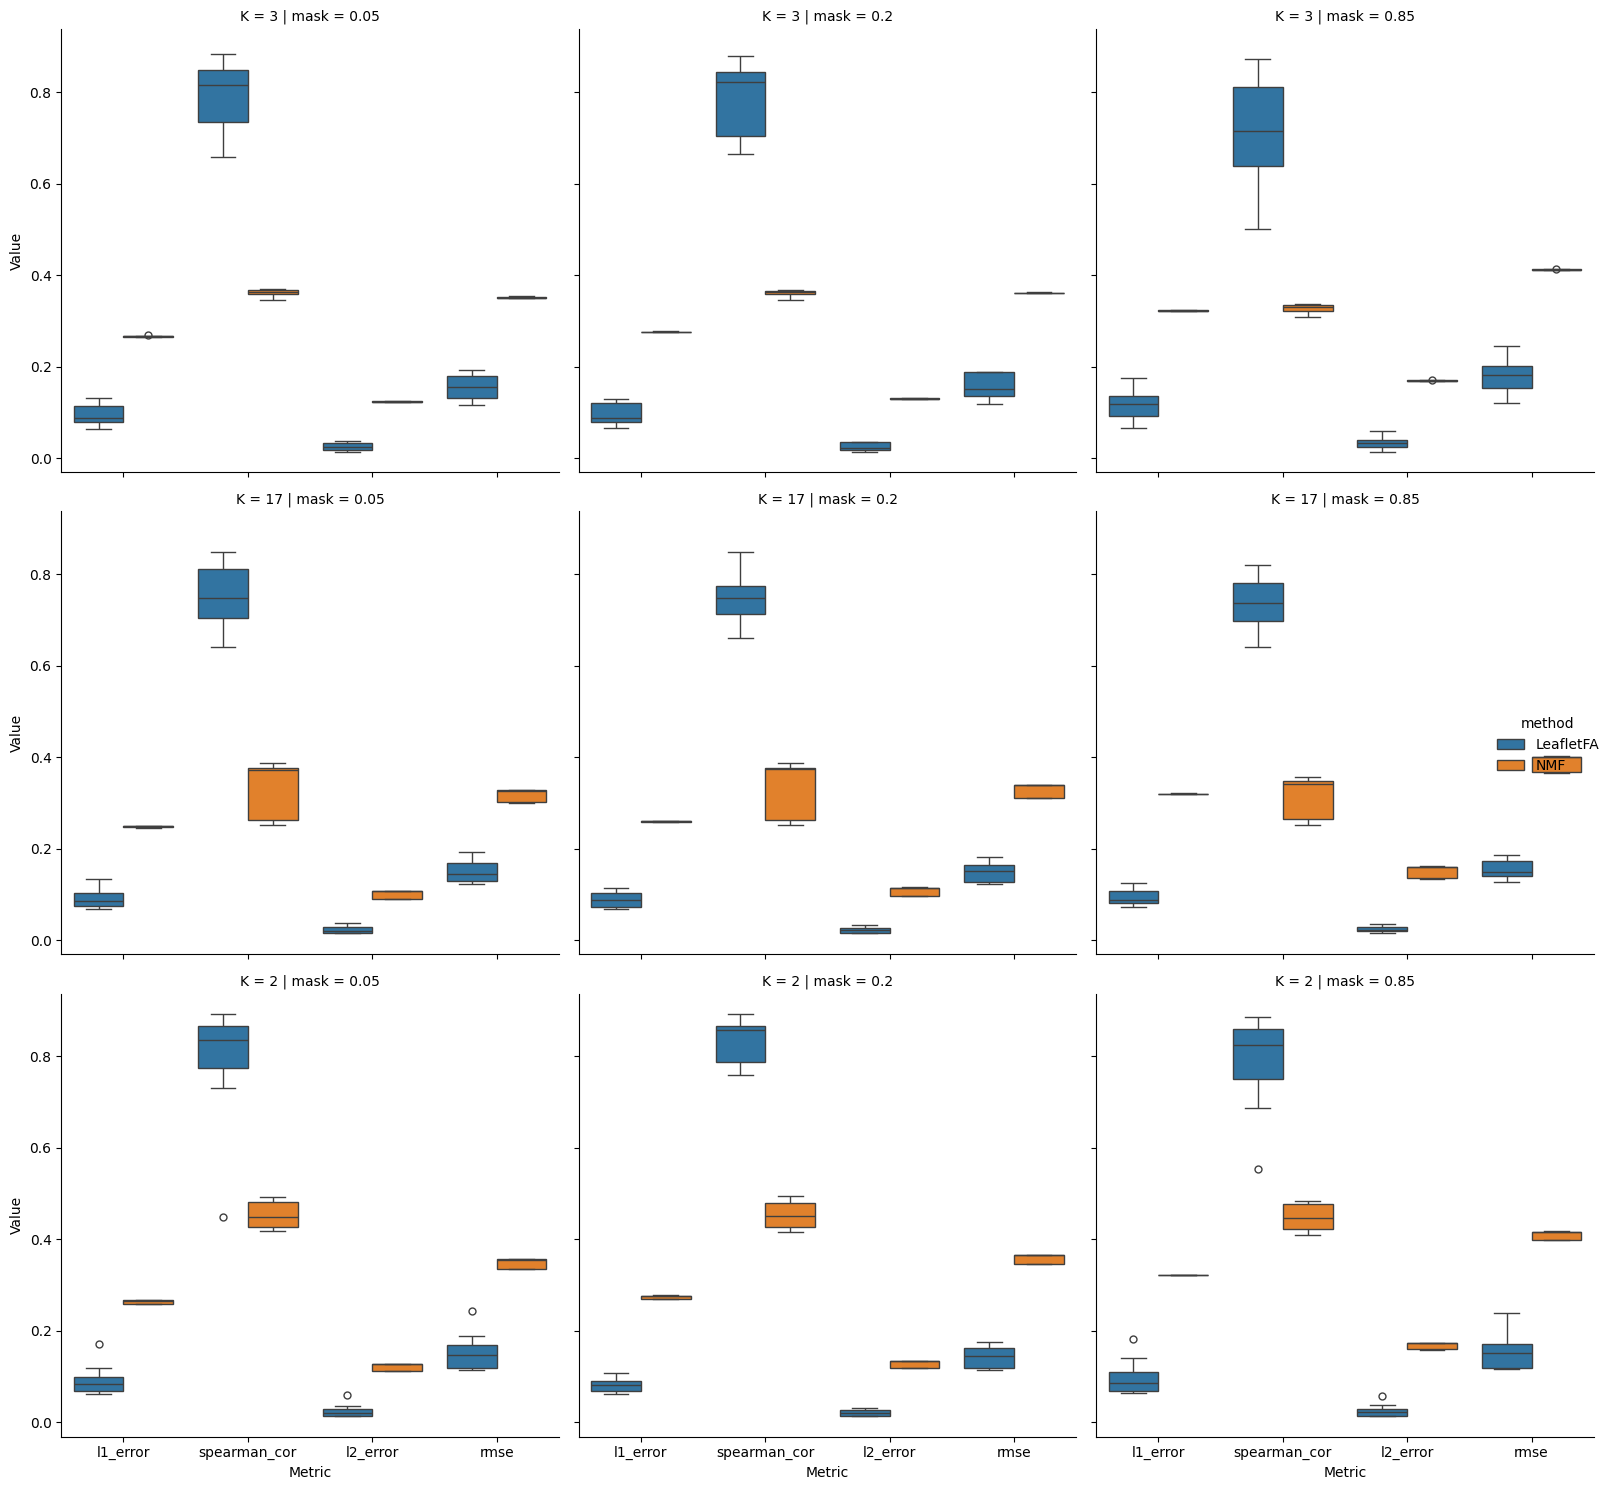

In [54]:
sns.catplot(
    data=concatenated_df, x='Metric', y='Value', hue="method",
    col='mask', row="K", kind='box'
)

# Adjust the layout and show the plot
plt.tight_layout()
plt.show()

In [48]:
concatenated_df[concatenated_df["mask"] == 0.85]

,method,mask,use_global_prior,input_conc,Metric,Value,K,CellType
6,LeafletFA,0.85,False,binomial,l1_error,0.174521,3,NoCellType
7,LeafletFA,0.85,False,binomial,l1_error,0.138529,3,NoCellType
8,LeafletFA,0.85,False,binomial,l1_error,0.147057,3,NoCellType
11,NMF,0.85,False,binomial,l1_error,0.322919,3,NoCellType
18,LeafletFA,0.85,False,binomial,spearman_cor,0.500182,3,NoCellType
...,...,...,...,...,...,...,...,...
1283,NMF,0.85,False,binomial,l2_error,0.160947,17,CellType
1290,LeafletFA,0.85,False,binomial,rmse,0.141358,17,CellType
1291,LeafletFA,0.85,False,binomial,rmse,0.140728,17,CellType
1292,LeafletFA,0.85,False,binomial,rmse,0.145423,17,CellType


In [55]:
celltype = concatenated_df[concatenated_df["CellType"] == "CellType"]
celltype

,method,mask,use_global_prior,input_conc,Metric,Value,K,CellType
48,LeafletFA,0.05,False,beta-binomial,l1_error,0.073062,17,CellType
49,LeafletFA,0.05,False,beta-binomial,l1_error,0.077445,17,CellType
50,LeafletFA,0.05,False,beta-binomial,l1_error,0.072756,17,CellType
51,LeafletFA,0.20,False,beta-binomial,l1_error,0.074081,17,CellType
52,LeafletFA,0.20,False,beta-binomial,l1_error,0.073101,17,CellType
...,...,...,...,...,...,...,...,...
1291,LeafletFA,0.85,False,binomial,rmse,0.140728,17,CellType
1292,LeafletFA,0.85,False,binomial,rmse,0.145423,17,CellType
1293,NMF,0.05,False,binomial,rmse,0.328593,17,CellType
1294,NMF,0.20,False,binomial,rmse,0.339839,17,CellType


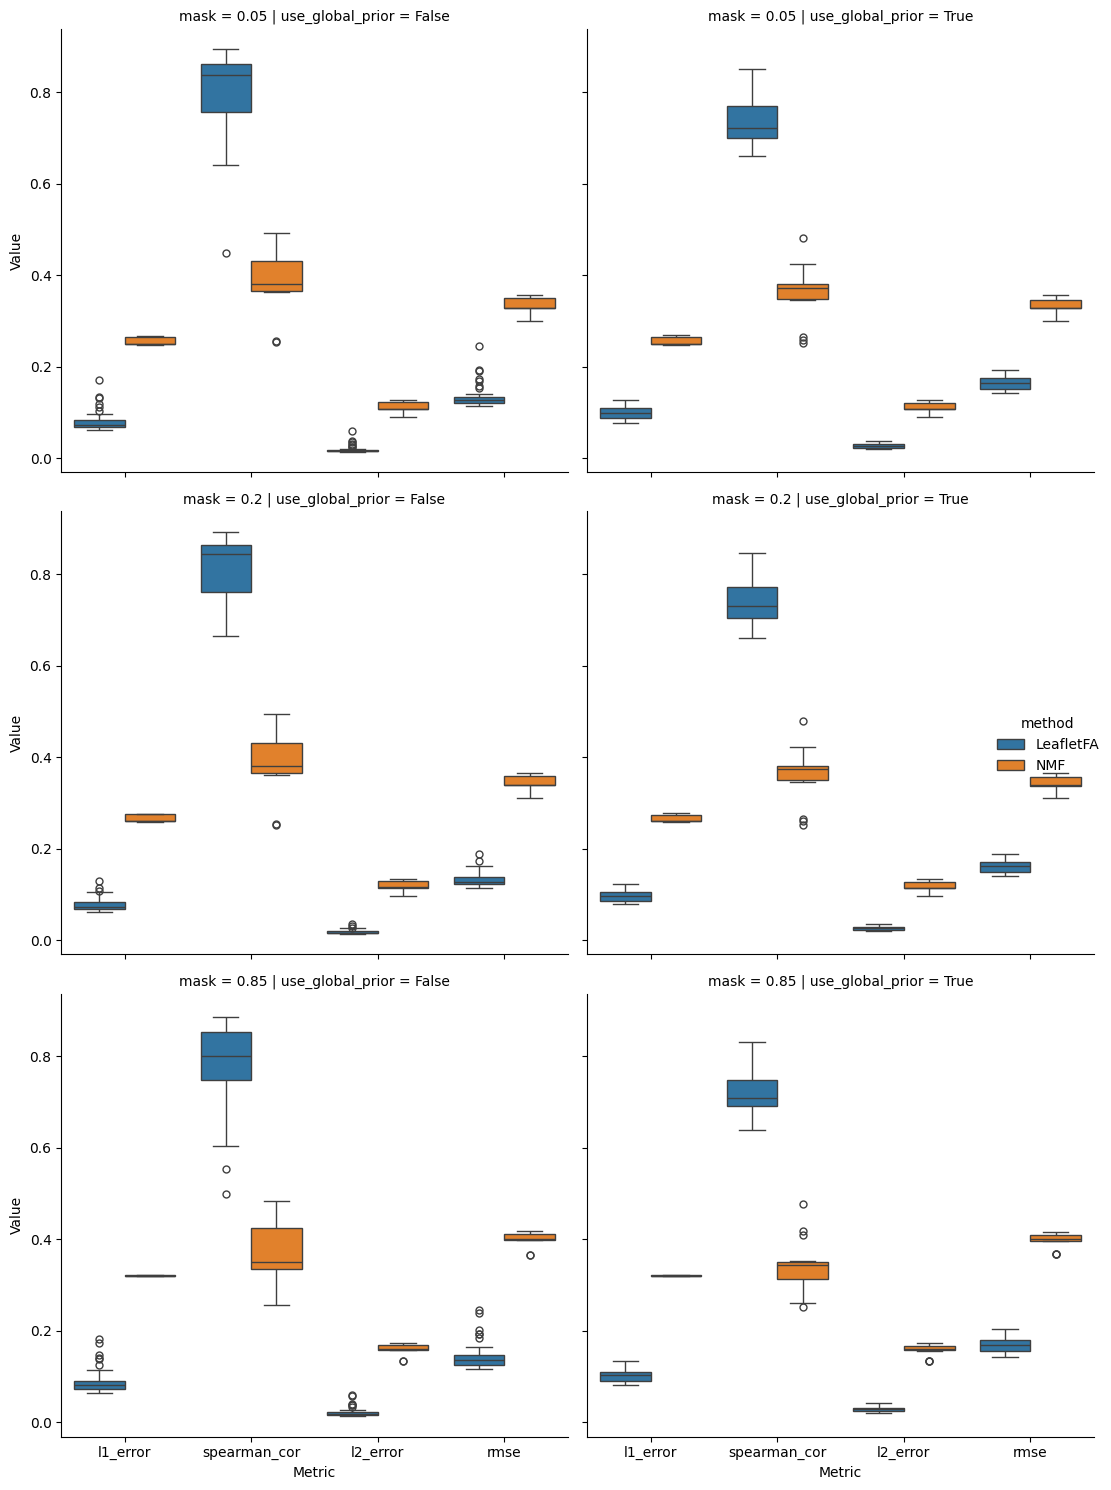

In [58]:
sns.catplot(
    data=concatenated_df, x='Metric', y='Value', hue="method",
    col='use_global_prior', row="mask", kind='box'
)

# Adjust the layout and show the plot
plt.tight_layout()
plt.show()